# Logistic Regression on Win Column

This notebook will build and train a logistic regression model to classify each match into win/loss. We will do this on three versions of our dataset. One will be trained on the usual dataset, one on just the odds, and one on the dataset without odds. The reason we will do this is to investigate the effect that the odds columns have on prediction. Since these are win probabilities given by bookmakers, they are a very good prediction of who will win the match. They already include much of the information given by the other columns in the dataset, since this is publicly available information and bookmaker models would have taken exactly this information into account when producing the odds. Hence, it may be the case that odds are extremely good predictor of win/loss, and all other columns are redundant. On the other hand, it may be the case that the other columns are able to give a good prediction of the gap between the true win probability and the bookmaker-predicted win probability. This is what we will explore with the different datasets.

## 1. Preparing the Data

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import shuffle_data_df, train_test_split_df, standardise

sns.set_style("whitegrid")

df = pd.read_csv("../Data/c_w_data.csv")
df = df.copy().drop(columns=['Score'])


df.head()

,Series,Surface,Round,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,5SMA
0,International,Clay,2nd Round,417,97,5.00,1170,28,1.14,0,18,1,0,1.000000
1,Masters,Hard,1st Round,440,97,3.50,1385,18,1.28,0,18,1,0,0.500000
2,Grand Slam,Hard,1st Round,431,97,2.50,825,43,1.50,1,18,1,1,0.333333
3,Grand Slam,Hard,2nd Round,431,97,3.50,1230,24,1.28,1,18,1,1,0.500000
4,Grand Slam,Hard,3rd Round,431,97,2.75,770,48,1.39,0,18,1,1,0.600000


In [18]:
# Shuffle data
df_shuff = shuffle_data_df(df)
df_shuff.head()

,Series,Surface,Round,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,5SMA
1057,Masters 1000,Clay,The Final,8260,1,1.440,5750,5,2.75,1,35,1,0,0.8
938,Grand Slam,Grass,The Final,12415,1,1.550,6620,3,2.60,1,32,1,1,1.0
1228,ATP250,Hard,Quarterfinals,4580,5,1.170,1120,47,5.00,1,38,0,0,0.8
683,Grand Slam,Clay,1st Round,13845,1,1.002,603,87,34.00,1,28,1,1,1.0
282,ATP500,Hard,The Final,7330,4,1.360,2195,15,3.20,1,22,1,0,0.8


In [19]:
# Train test split
df_train, df_test = train_test_split_df(df_shuff, 0.8)

## 2. Logistic Regression Model / Functions

In [107]:
def stable_sigmoid(x):
    

    return np.where(x >= 0, 1. / ( 1. + np.exp(-x)), np.exp(x) / ( 1. + np.exp(x) ))

In [81]:
def binary_cross_entrop(y_true, probs, eps=1e-7):

    """
        Computes the binary cross entrop given a vector of true binary labels and a vector of
        probability predictions
    """

    probs = np.clip(probs, eps, 1-eps)
    return - np.mean(y_true * np.log(probs) + (1 - y_true) * (1 - np.log(probs)))

In [21]:
def bce_grad(X, y_true, probs):

    """
        Computes the gradient of the binary cross-entropy with respect to theta.
    """

    return (1 / X.shape[0]) * X.T @ (probs - y_true)

In [ ]:
def gradient_descent(X, y, lr=1e-3, iter=10000, thresh=1e-7):

    """
        This is a gradient descent training loop for logistic regression.
    """

    # Initialise coefficients, probabilities vector and loss array
    theta = np.ones((X.shape[1], 1))
    losses = []

    # Begin descent loop
    for i in range(iter):

        # Calculate probabilities
        z = (X @ theta).reshape(-1, 1)
        probs = stable_sigmoid(z)

        # Calculate binary cross entropy and gradient
        loss = binary_cross_entrop(y, probs)
        losses.append(float(loss))
        grad = bce_grad(X, y, probs)

        # Print loss every 200th iteration number
        if (i+1) % 200 == 0:
            print(f"Iteration {i+1}")
            print("Loss", loss)

        # Update theta
        theta_new = theta - lr * grad

        # Check for early convergence
        if np.linalg.norm(grad) <= thresh:
            print(fr"We have reached early convergence on iteration {i+1}.")
            return theta_new

        # Update theta
        theta = theta_new

    print(fr"Reached max iterations.")
    return theta, losses

In [115]:
def hard_thresh(probs):

    """
        Calculate the 1/0 prediction from the probability scores
    """

    return np.where(probs >= 0.5, 1, 0)

In [116]:
def accuracy(y_true, y_hat):

    """
        Calculates the accuracy of the model. y_true are the true labels and y_hat are the hard
        thresholded probabilities.
    """

    return np.mean(y_true == y_hat)

## 3. Odds Dataset

We begin with a dataset containing only the odds columns, and evaluate how well it predicts Djokovic's win probability. First let us prepare the data for this specific task.

In [76]:
# Forming dataset
df_odds_train = df_train.copy()[['dj_odds', 'opp_odds', 'dj_win']]
df_odds_test = df_test.copy()[['dj_odds', 'opp_odds', 'dj_win']]

In [77]:
df_odds_train.head()

,dj_odds,opp_odds,dj_win
1057,1.440,2.75,1
938,1.550,2.60,1
1228,1.170,5.00,1
683,1.002,34.00,1
282,1.360,3.20,1


In [78]:
# Separating target from predictors
y_train, y_test = df_odds_train['dj_win'].to_numpy().reshape(-1, 1), df_odds_test['dj_win'].to_numpy().reshape(-1, 1)
X_train, X_test = df_odds_train[['dj_odds', 'opp_odds']].to_numpy(), df_odds_test[['dj_odds', 'opp_odds']].to_numpy()

In [87]:
# Standardise and augment prediction matrix
X_train_std = standardise(X_train)
X_test_std = standardise(X_test, X_train)

X_train_sa = np.concatenate([np.ones((X_train_std.shape[0], 1)), X_train_std], axis=1)
X_test_sa = np.concatenate([np.ones((X_test_std.shape[0], 1)), X_test_std], axis=1)

Now that our data is fully separated, standardised, and augmented, we can train our model.

In [118]:
# Train the model
theta, losses = gradient_descent(X_train_sa, y_train, iter=500000)

Iteration 200
Loss 0.10264844253677498
Iteration 400
Loss 0.09527465892739946
Iteration 600
Loss 0.08834477592881476
Iteration 800
Loss 0.08182473570994546
Iteration 1000
Loss 0.07568341269981427
Iteration 1200
Loss 0.06989234047490753
Iteration 1400
Loss 0.06442546246005731
Iteration 1600
Loss 0.05925890498297456
Iteration 1800
Loss 0.05437077112494671
Iteration 2000
Loss 0.04974095378448981
Iteration 2200
Loss 0.0453509663965377
Iteration 2400
Loss 0.04118378981133953
Iteration 2600
Loss 0.03722373392290852
Iteration 2800
Loss 0.033456312737983024
Iteration 3000
Loss 0.029868131686893017
Iteration 3200
Loss 0.026446786093324653
Iteration 3400
Loss 0.023180769838082673
Iteration 3600
Loss 0.020059393371010804
Iteration 3800
Loss 0.01707271034454843
Iteration 4000
Loss 0.014211452261517998
Iteration 4200
Loss 0.011466970648191568
Iteration 4400
Loss 0.008831186380211548
Iteration 4600
Loss 0.006296545900641327
Iteration 4800
Loss 0.0038559841707240315
Iteration 5000
Loss 0.001502894275

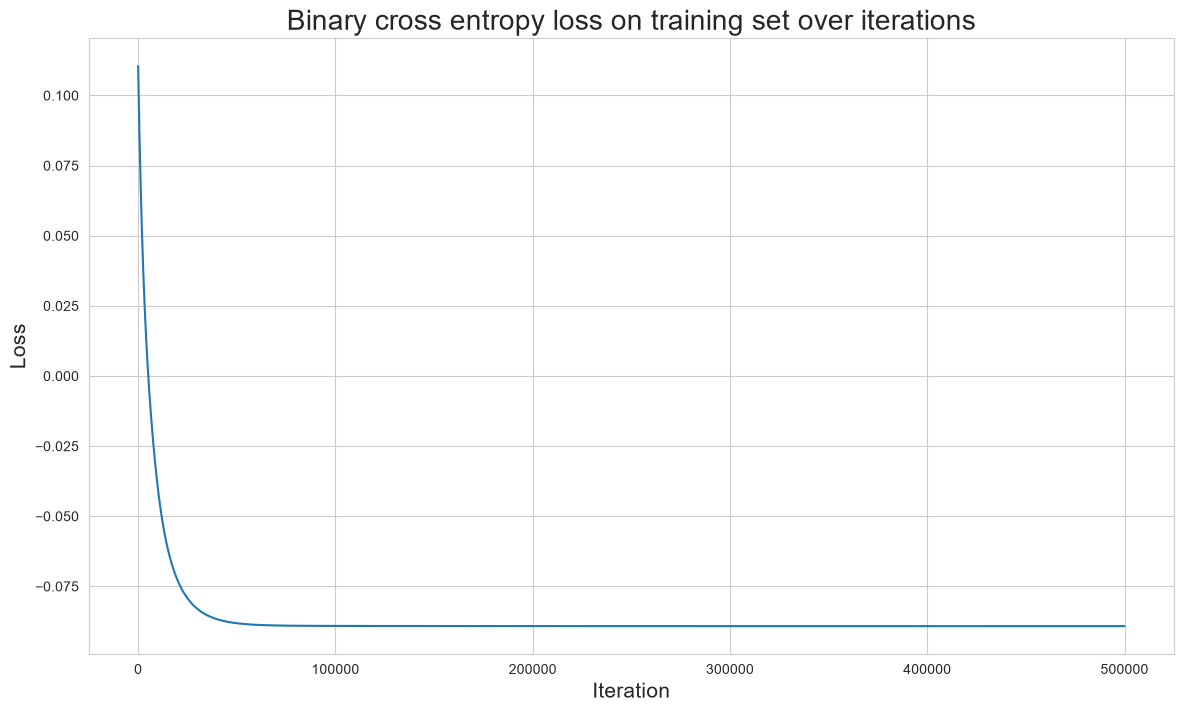

In [119]:
# Plotting the training binary cross entropy (loss) curve
plt.figure(figsize=(14, 8))
plt.plot(losses)
plt.xlabel("Iteration", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.title("Binary cross entropy loss on training set over iterations", fontsize=20)
plt.show()
